<div style="display: flex; background-color: RGB(255,114,0);" >
<h1 style="margin: auto; padding: 30px; ">ANALYSE DU STOCK ET DES VENTES DU SITE BOTTLENECK</h1>
</div>

# OBJECTIF DE CE NOTEBOOK

L'entreprise Bottleneck est une entreprise spécialisée dans la vente de vins prestigieux.

Ma mission se découpe en 2 phases :

Phase 1 : Agréger les différents fichiers afin d'exploiter les données.

Phase 2 : Analyser les données pour les présenter au comité de direction.



<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 1 - Importation des librairies et chargement des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.1 - Importation des librairies</h3>
</div>

In [602]:
#Importation de la librairie Pandas
import pandas as pd

In [604]:
#Importation de la librairie plotly express
import plotly.express as px

In [605]:
#Trouver dans Google l'instruction permettant d'afficher toutes les colonnes d'un dataframe
#Saisir, dans Google, les mots clés "display all columns dataframe Pandas", par exemple.
#Dans les résultats de la recherche, privilégiez les solutions provenants de Stack Overflow ou Medium
pd.set_option('display.max_columns', None)

In [608]:
#Ne pas afficher l'avertissement concernant openpyxl
import warnings
warnings.simplefilter("ignore")

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">1.2 - Chargements des fichiers</h3>
</div>

In [611]:
#Importation du fichier web.xlsx
df_web = pd.read_excel("web.xlsx")
#Importation du fichier erp.xlsx
df_erp = pd.read_excel("erp.xlsx")
#importation du fichier liaison.xlsx
df_liaison = pd.read_excel("liaison.xlsx")

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 2 - Analyse exploratoire des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1 - Analyse exploratoire du fichier erp.xlsx</h3>
</div>

In [614]:
#Afficher les dimensions du dataset
print("Le tableau comporte {} observation(s) ou article(s)".format(df_erp.shape[0]))
print("Le tableau comporte {} colonne(s)".format(df_erp.shape[1]))

Le tableau comporte 825 observation(s) ou article(s)
Le tableau comporte 6 colonne(s)


In [616]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_erp.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   product_id      825 non-null    int64  
 1   onsale_web      825 non-null    int64  
 2   price           825 non-null    float64
 3   stock_quantity  825 non-null    int64  
 4   stock_status    825 non-null    object 
 5   purchase_price  825 non-null    float64
dtypes: float64(2), int64(3), object(1)
memory usage: 38.8+ KB


In [618]:
#Afficher les 5 premières lignes de la table
df_erp.head()

#On peut constater que le product_id 4039 est 'outofstock' alors qu'il y en a 3 en stock. 

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price
0,3847,1,24.2,16,instock,12.88
1,3849,1,34.3,10,instock,17.54
2,3850,1,20.8,0,outofstock,10.64
3,4032,1,14.1,26,instock,6.92
4,4039,1,46.0,3,outofstock,23.77


In [621]:
#Vérifier si il y a les lignes en doublons dans la colonne product_id
df_erp.loc[df_erp['product_id'].duplicated(keep=False),:]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price


In [623]:
#Afficher les valeurs distinctes de la colonne stock_status
#À quelle(s) autre(s) colonne(s) sont-elles liées ?
df_erp['stock_status'].unique()

array(['instock', 'outofstock'], dtype=object)

In [625]:
#Création d'une colonne "stock_status_2"
#La valeur de cette deuxième colonne sera fonction de la valeur dans la colonne "stock_quantity"
#si la valeur de la colonne "stock_quantity" est nulle renseigner "outofstock" sinon mettre "instock"
df_erp['stock_status_2'] = df_erp['stock_quantity'].apply(lambda x: 'outofstock' if x <= 0 else 'instock')
df_erp.head()

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
0,3847,1,24.2,16,instock,12.88,instock
1,3849,1,34.3,10,instock,17.54,instock
2,3850,1,20.8,0,outofstock,10.64,outofstock
3,4032,1,14.1,26,instock,6.92,instock
4,4039,1,46.0,3,outofstock,23.77,instock


In [627]:
#Vérifions que les 2 colonnes sont identiques:
#Les 2 colonnes sont strictement identiques si les valeurs de chaque ligne sont strictement identiques 2 à 2
#La comparaison de 2 colonnes peut se réaliser simplement avec l'instruction ci-dessous:
df_erp["stock_status"] == df_erp["stock_status_2"]
#Le résultat est l'affichage de True ou False pour chacune des lignes du dataset
#C'est un bon début, mais difficile à exploiter

0       True
1       True
2       True
3       True
4      False
       ...  
820     True
821     True
822     True
823     True
824     True
Length: 825, dtype: bool

In [629]:
#Mais il est possible de synthétiser ce résultat en effectuant la somme de cette colonne:
#True vaut 1 et False 0

(df_erp["stock_status"] == df_erp["stock_status_2"]).sum()

823

In [631]:
#Si les colonnes ne sont absolument pas identiques ligne à ligne alors identifier la ligne en écart
##Dans ce cas je vous ce lien pour apprendre à réaliser des filtres dans Pandas:
##https://bitbucket.org/hrojas/learn-pandas/src/master/
##Lesson 3

df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]

#On constate que la colonne 'stock_status' comporte des erreurs

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
4,4039,1,46.0,3,outofstock,23.77,instock
398,4885,1,18.7,0,instock,9.66,outofstock


In [633]:
#Corriger la ou les données incohérentes
df_erp.loc[df_erp['product_id'] == 4039, 'stock_status'] = 'instock'
df_erp.loc[df_erp['product_id'] == 4885, 'stock_status'] = 'outofstock'

#Vérification en utilisant le même code que plus haut pour afficher les problemes

df_erp[df_erp["stock_status"] != df_erp["stock_status_2"]]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1 - Analyse exploratoire de chaque variable du fichier erp.xlsx</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.1 - Analyse de la variable PRIX</h3>
</div>

In [637]:
###############
## LES PRIX  ##
###############

#Vérification des prix: Y a t-il des prix non renseignés, négatif ou nul?
# Vérifier si des prix sont non renseignés
prix_non_renseignes = df_erp[df_erp['price'].isna()]

# Vérifier si des prix sont négatifs
prix_negatifs = df_erp[df_erp['price'] < 0]

# Vérifier si des prix sont nuls
prix_nuls = df_erp[df_erp['price'] == 0]

print(prix_non_renseignes)
print(prix_negatifs)
print(prix_nuls)


#Afficher le ou les prix non renseignés dans la colonne "price"
nombre_prix_non_renseignes = df_erp['price'].isna().sum()
print("\nLe nombre d'article avec un prix non renseigné est de: {}".format(nombre_prix_non_renseignes))

#Afficher le prix minimum de la colonne "price"
prix_minimum = df_erp['price'].min()
print("Le prix minimum est de: {}".format(prix_minimum))

#Afficher le prix maximum de la colonne "price"
prix_maximum = df_erp['price'].max()
print("Le prix maximum est de: {}".format(prix_maximum))

#Afficher les prix inférieurs à 0 (qu'est ce qu'il faut en faire ?)
print("\nLes articles avec des prix inférieurs à 0 sont:")
print(prix_negatifs)

#1)Remonter l'information concernant les prix négatifs
#2)Produit non vendu sur internet 'on_sale' 0
#3)Il faudrait les supprimer car ce sont des prix négatifs pour la suite de l'analyse (-20, -8 et -9.1)
#4)Etant donné que '6594' possède 19 quantités il n'est pas pertinant de basculer les prix à 0 pour faciliter l'analyse


Empty DataFrame
Columns: [product_id, onsale_web, price, stock_quantity, stock_status, purchase_price, stock_status_2]
Index: []
     product_id  onsale_web  price  stock_quantity stock_status  \
151        4233           0  -20.0               0   outofstock   
469        5017           0   -8.0               0   outofstock   
739        6594           0   -9.1              19      instock   

     purchase_price stock_status_2  
151           10.33     outofstock  
469            4.34     outofstock  
739            4.61        instock  
Empty DataFrame
Columns: [product_id, onsale_web, price, stock_quantity, stock_status, purchase_price, stock_status_2]
Index: []

Le nombre d'article avec un prix non renseigné est de: 0
Le prix minimum est de: -20.0
Le prix maximum est de: 225.0

Les articles avec des prix inférieurs à 0 sont:
     product_id  onsale_web  price  stock_quantity stock_status  \
151        4233           0  -20.0               0   outofstock   
469        5017         

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.2 - Analyse de la variable STOCK</h3>
</div>

In [640]:
#######################
### stock_quantity  ###
#######################

#Vérification de la colonne stock quantity
#Afficher la quantité minimum de la colonne "stock_quantity"
quantite_minimum = df_erp['stock_quantity'].min()
print("Quantite minimum: {}".format(quantite_minimum))
#Afficher la quantité maximum de la colonne "stock_quantity"
quantite_maximum = df_erp['stock_quantity'].max()
print("Quantite maximum: {}".format(quantite_maximum))
#Afficher les stocks inférieurs à 0 (qu'est ce qu'il faut en faire ?)
df_erp[df_erp['stock_quantity'] < 0]

#Il faut supprimer les lignes  449 et 573 

Quantite minimum: -10
Quantite maximum: 145


,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,stock_status_2
449,4973,0,10.0,-10,outofstock,4.96,outofstock
573,5700,1,44.5,-1,outofstock,22.30,outofstock


In [642]:
#Voir avec le service concerné pour comprendre et remonter le problème de stock négatif

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.3 - Analyse de la variable ONSALE_WEB</h3>
</div>

In [645]:
#Vérification de la colonne onsale_web et des valeurs qu'elle contient? Que signifient-elles?

#Afficher les valeurs uniques présentes dans la colonne "onsale_web"
valeurs_onsale_web = df_erp['onsale_web'].unique()
print("Les valeurs uniques dans la colonne 'onsale_web' sont : {}".format(valeurs_onsale_web))

#Cela signifique qu'il y a deux valeurs unique présentes dans la colonne (1 et 0) avec la liste des produits présents sur le site 1 ou 0
#pour ceux non présent

Les valeurs uniques dans la colonne 'onsale_web' sont : [1 0]


In [647]:
#Quelles sont les colonnes à conserver selon vous?

#Pour moi, il est important de conserver les colonnes 'product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status',
#'purchase_price'

df_erp.columns

Index(['product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status',
       'purchase_price', 'stock_status_2'],
      dtype='object')

In [649]:
#Supprimer la colonne comportant le libellé "stock_status_2" car elle est redondante 
#avec la colonne "stock_status".
df_erp = df_erp.drop(columns=['stock_status_2'])
#Verification si la colonne a bien été supprimé
df_erp.columns

Index(['product_id', 'onsale_web', 'price', 'stock_quantity', 'stock_status',
       'purchase_price'],
      dtype='object')

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.1.1.4 - Analyse de la variable prix d'achat</h3>
</div>

In [652]:
######################
##   prix d'achat   ##
######################

#Vérification de la colonne purchase_price : 
#Afficher le ou les prix non renseignés dans la colonne "purchase_price"
nombre_prix_achat_non_renseignes = df_erp['purchase_price'].isna().sum()
print("Le nombres d'articles avec un prix d'achat non renseignés est de : {}".format(nombre_prix_achat_non_renseignes))
#Afficher le prix minimum de la colonne "purchase_price"
prix_achat_minimum = df_erp['purchase_price'].min()
print("Le prix d'achat minimum est de : {}".format(prix_achat_minimum))
#Afficher le prix maximum de la colonne "purchase_price"
prix_achat_maximum = df_erp['purchase_price'].max()
print("Le prix d'achat maximum est de: {}".format(prix_achat_maximum))

Le nombres d'articles avec un prix d'achat non renseignés est de : 0
Le prix d'achat minimum est de : 2.74
Le prix d'achat maximum est de: 137.81


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.2 - Analyse exploratoire du fichier web.xlsx</h3>
</div>
 

In [655]:
#Dimension du dataset
dimensions_web = df_web.shape

#Nombre d'observations
nombre_observations = dimensions_web[0]

#Nombre de caractéristiques
nombre_caracteristiques = dimensions_web[1]

#Afficher les dimensions du dataset (nombre d'observations et de caractéristiques)
print("Le nombre d'observation est de {}".format(nombre_observations))
print("Il y a {} colonnes".format(nombre_caracteristiques))

Le nombre d'observation est de 1513
Il y a 29 colonnes


In [657]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_web.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1513 entries, 0 to 1512
Data columns (total 29 columns):
 #   Column                 Non-Null Count  Dtype         
---  ------                 --------------  -----         
 0   sku                    1428 non-null   object        
 1   virtual                1513 non-null   int64         
 2   downloadable           1513 non-null   int64         
 3   rating_count           1513 non-null   int64         
 4   average_rating         1430 non-null   float64       
 5   total_sales            1430 non-null   float64       
 6   tax_status             716 non-null    object        
 7   tax_class              0 non-null      float64       
 8   post_author            1430 non-null   float64       
 9   post_date              1430 non-null   datetime64[ns]
 10  post_date_gmt          1430 non-null   datetime64[ns]
 11  post_content           0 non-null      float64       
 12  product_type           1429 non-null   object        
 13  pos

In [659]:
#Selon vous, quelles sont les colonnes à conserver ?
#Les colonnes à conserver sont : 'sku', 'total_sales', 'product_type', 'post_title', 'tax_status', 'post_mime_type', 'post_type'

In [661]:
#Si vous avez défini des colonnes à supprimer, effectuer l'opération
#Les colonnes sont à supprimer car inutile pour les analyses

colonnes_a_supprimer = [
    'virtual', 'downloadable', 'rating_count', 'average_rating', 'tax_class', 'post_author',
    'post_date', 'post_date_gmt', 'post_content', 'post_excerpt', 'post_status', 'ping_status', 'comment_status',
    'post_name', 'post_password', 'guid', 'post_modified', 'post_modified_gmt', 'post_parent', 'post_content_filtered', 'menu_order',
    'comment_count'
]

df_web = df_web.drop(columns=colonnes_a_supprimer)

#Verification si les colonnes ont bien été supprimé
df_web.columns

Index(['sku', 'total_sales', 'tax_status', 'product_type', 'post_title',
       'post_type', 'post_mime_type'],
      dtype='object')

In [663]:
#Visualisation des valeurs de la colonne sku
#Quelles sont les valeurs qui ne semblent pas respecter la régle de codification?
df_web['sku'].unique()

array([11862, 16057, 14692, 16295, 15328, 15471, 16515, 16246, nan, 13572,
       16513, 16585, 16269, 15526, 12869, 15575, 11586, 14338, 15425,
       16560, 15361, 13809, 11587, 15022, 14323, 16342, 16029, 15475,
       13754, 14680, 15875, 9636, 13849, 13662, 16564, 13557, 15429,
       14712, 15032, 15481, 15448, 16580, 15441, 804, 15300, 13958, 16071,
       15678, 13895, 15711, 12882, 16053, 13766, 16247, 12640, 15292,
       15476, 15670, 16189, 16038, 14864, 16044, 15324, 15531, 15953,
       15413, 15733, 14366, 15895, 15892, 16472, 15185, 16010, 15793,
       15849, 12315, 15741, 15934, 15148, 15781, 15659, 15106, 15490,
       14507, 14149, 16307, 13736, 14090, 16037, 15758, 14661, 12587,
       15337, 15489, 15201, 16305, 16131, 13435, 15747, 12203, 14509,
       14768, 16262, 14561, 16505, 15717, 16129, 13460, 15871, 15940,
       11602, 13127, 13520, 15480, 13032, 15436, 15269, 15910, 19821,
       16263, 15138, 15146, 15126, 15482, 16186, 13905, 16540, 15856,
       1567

In [665]:
#'Bon-cadeau-25-euros' , '13127-1', 'nan' n'ont pas les bons formats
#A voir si certains sku qui ont < 5 sont conformes avec le service concerné

In [669]:
#Si vous avez identifié des codes articles ne respectant pas la régle de codification, consultez-les?
#Déterminer les différents types dans la colonne 'sku'
sku_types = df_web['sku'].apply(type).value_counts()
print(sku_types)

#Conversion de la colonne 'sku' en string 
df_web['sku_str'] = df_web['sku'].astype(str)

#Rechercher toutes les lignes de la colonne 'sku' contenant plus de 5 caractères (recherche format incorrect)
lignes_plus_5 = df_web[df_web['sku_str'].str.len() > 5]

#Filtrer les valeurs nulles avant conversion
df_web_non_null = df_web[df_web['sku'].notna()].copy()

#Création d'une colonne 'sku_str' pour sécuriser la dataframe + changer les valeurs en texte
df_web_non_null.loc[:, 'sku_str'] = df_web_non_null['sku'].astype(str)

#Rechercher toutes les lignes de la colonne 'sku' contenant entre 1 et 4 caractères sans les cellules vides
lignes_mauvais_format = df_web_non_null[df_web_non_null['sku_str'].str.len().between(1, 4)]

#Afficher les lignes identifiées
print("\nLignes avec les sku inférieur à 5 sont:")
lignes_mauvais_format

"\nLignes avec les 'sku' supérieur à 5 sont:"
lignes_plus_5

sku
<class 'int'>      1424
<class 'float'>      85
<class 'str'>         4
Name: count, dtype: int64

Lignes avec les sku inférieur à 5 sont:


,sku,total_sales,tax_status,product_type,post_title,post_type,post_mime_type,sku_str
272,13127-1,4.0,taxable,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,product,NaN,13127-1
842,bon-cadeau-25-euros,7.0,NaN,Autre,Bon cadeau de 25€,attachment,image/jpeg,bon-cadeau-25-euros
1117,13127-1,4.0,NaN,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,attachment,image/jpeg,13127-1
1387,bon-cadeau-25-euros,7.0,taxable,NaN,Bon cadeau de 25€,product,NaN,bon-cadeau-25-euros


In [671]:
#Suppression du 'bon-cadeau-25-euros'
df_web = df_web[df_web['sku'] != 'bon-cadeau-25-euros'] 

In [673]:
#Nombre de sku non renseigné
nombre_sku_non_renseignes = df_web['sku'].isna().sum()
print("Il y a {} articles avec un sku non renseigné".format(nombre_sku_non_renseignes))

#Identifier les lignes sans code articles
liste_sku_renseignes = df_web[df_web['sku'].isna()]
liste_sku_renseignes

#Liste assez importante d'articles sans sku et sans informations = à supprimer

Il y a 85 articles avec un sku non renseigné


,sku,total_sales,tax_status,product_type,post_title,post_type,post_mime_type,sku_str
8,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan
20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan
30,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan
37,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan
41,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan
...,...,...,...,...,...,...,...,...
1384,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan
1429,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan
1432,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan
1445,NaN,NaN,NaN,NaN,NaN,NaN,NaN,nan


In [675]:
#Affichage de la ligne avec comme sku '13127-1'
df_web[df_web["sku"] == "13127-1"]

,sku,total_sales,tax_status,product_type,post_title,post_type,post_mime_type,sku_str
272,13127-1,4.0,taxable,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,product,NaN,13127-1
1117,13127-1,4.0,NaN,Vin,Clos du Mont-Olivet Châteauneuf-du-Pape 2007,attachment,image/jpeg,13127-1


In [677]:
#Il y a également deux lignes de la colonne 'total_sales' avec des  ventes négatives -56 et -17

ventes_negatives = df_web[df_web['total_sales'] < 0]
ventes_negatives

,sku,total_sales,tax_status,product_type,post_title,post_type,post_mime_type,sku_str
1084,NaN,-56.0,taxable,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,product,NaN,nan
1087,NaN,-17.0,taxable,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,product,NaN,nan


In [679]:
#Je conserve les lignes des ventes négatives car j'estime qu'ils doivent être envoyer et analyser pour voir si c'est une erreur ou non
#Par contre, j'ai bien identifié que les sku sont non renseignés et les ventes sont négatives

#Attribution de nouveau sku pour les 2 articles de vin
df_web.loc[1084, "sku"] = "inconnu_0"
df_web.loc[1087, "sku"] = "inconnu_1"

df_web.loc[[1084, 1087]]

,sku,total_sales,tax_status,product_type,post_title,post_type,post_mime_type,sku_str
1084,inconnu_0,-56.0,taxable,Vin,Pierre Jean Villa Condrieu Jardin Suspendu 2018,product,NaN,nan
1087,inconnu_1,-17.0,taxable,Vin,Pierre Jean Villa Côte Rôtie Fongeant 2017,product,NaN,nan


In [745]:
#Pour les codes articles identifiés, réalisé une analyse et définissez l'action à entreprendre
#Supprimer les lignes qui contiennent uniquement des NaN dans toutes les colonnes
df_nettoye = df_web.dropna(subset=['sku'])

#Afficher les lignes du dataframe nettoyé pour vérifier
df_nettoye

,sku,total_sales,tax_status,product_type,post_title,post_type,post_mime_type,sku_str
0,11862,3.0,NaN,Vin,Gilles Robin Hermitage Rouge 2012,attachment,image/jpeg,11862
1,16057,5.0,NaN,Vin,Domaine Pellé Sancerre Rouge La Croix Au Garde...,attachment,image/jpeg,16057
2,14692,5.0,taxable,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,product,NaN,14692
3,16295,14.0,NaN,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,attachment,image/jpeg,16295
4,15328,2.0,taxable,Vin,Agnès Levet Côte Rôtie Maestria 2017,product,NaN,15328
...,...,...,...,...,...,...,...,...
1508,16326,5.0,taxable,Vin,Camin Larredya Jurançon Moelleux Au Capcéu 2018,product,NaN,16326
1509,15662,15.0,taxable,Vin,Chermette Domaine du Vissoux Beaujolais Griott...,product,NaN,15662
1510,15329,3.0,NaN,Vin,Agnès Levet Côte Rôtie Péroline 2017,attachment,image/jpeg,15329
1511,14827,7.0,NaN,Vin,Marc Colin Et Fils Chassagne-Montrachet Blanc ...,attachment,image/jpeg,14827


In [683]:
#La clé pour chaque ligne est-elle unique? ou autrement dit, y a-t-il des doublons?

#Compter le nombre de doublons dans la colonne 'sku'
nombre_doublons = df_web['sku'].duplicated().sum()
print("Le nombre de doublons dans la colonne 'sku' est de: {}".format(nombre_doublons))

#Lister les valeurs de 'sku' qui apparaissent plus d'une fois
valeurs_doublons = df_web['sku'].value_counts()[df_web['sku'].value_counts() > 1]

#Afficher ces valeurs
valeurs_doublons

#La clé n'est pas unique.

Le nombre de doublons dans la colonne 'sku' est de: 795


sku
11862    2
16324    2
3507     2
14773    2
15967    2
        ..
12639    2
15466    2
15184    2
13078    2
15927    2
Name: count, Length: 713, dtype: int64

In [749]:
#Suppression des doublons de la colonne 'sku' en conservant uniquement les 'product' de la colonne 'post_type'
#Filtrer les lignes contenant 'product' dans la colonne 'post_type'
#Afficher le dataframe filtré sans les doublons
df_web = df_web[df_web["post_type"] == "product"]
#Vérification des doublons
print("Après suppression des doublons, le nombre de lignes est de:", len(df_web))

Après suppression des doublons, le nombre de lignes est de: 715


In [753]:
#Afficher le dataframe filtré sans les doublons
df_web

,sku,total_sales,tax_status,product_type,post_title,post_type,post_mime_type,sku_str
2,14692,5.0,taxable,Vin,Château Fonréaud Bordeaux Blanc Le Cygne 2016,product,NaN,14692
4,15328,2.0,taxable,Vin,Agnès Levet Côte Rôtie Maestria 2017,product,NaN,15328
6,16515,10.0,taxable,Vin,Château Turcaud Bordeaux Rouge Cuvée Majeure 2018,product,NaN,16515
11,16585,15.0,taxable,Vin,Xavier Frissant Touraine Sauvignon 2019,product,NaN,16585
14,12869,7.0,taxable,Vin,Stéphane Tissot Arbois D.D. 2016,product,NaN,12869
...,...,...,...,...,...,...,...,...
1503,13074,4.0,taxable,Vin,Château de Vaudieu Châteauneuf-du-Pape L'Avenu...,product,NaN,13074
1505,16322,0.0,taxable,Vin,Moulin de Gassac IGP Pays d'Hérault Guilhem Ro...,product,NaN,16322
1507,12365,10.0,taxable,Vin,Parés Baltà Penedès Electio 2013,product,NaN,12365
1508,16326,5.0,taxable,Vin,Camin Larredya Jurançon Moelleux Au Capcéu 2018,product,NaN,16326


In [751]:
#Les lignes sans code article semble être toutes non renseignés
#Pour s'en assurer réaliser les étapes suivantes:
#1 - Créer un dataframe avec uniquement les lignes sans code article
df_sans_code_article = df_web[df_web['sku'].isna()]
#2 - utiliser la fonction df.info() sur ce nouveau dataframe pour observer le nombre de valeur renseigner dans chacune des colonnes
df_sans_code_article.info()
#3 - Que constatez-vous?
#Les valeurs non-null n'apparaissent plus (sauf sku_str)

<class 'pandas.core.frame.DataFrame'>
Index: 0 entries
Data columns (total 8 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   sku             0 non-null      object 
 1   total_sales     0 non-null      float64
 2   tax_status      0 non-null      object 
 3   product_type    0 non-null      object 
 4   post_title      0 non-null      object 
 5   post_type       0 non-null      object 
 6   post_mime_type  0 non-null      object 
 7   sku_str         0 non-null      object 
dtypes: float64(1), object(7)
memory usage: 0.0+ bytes


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">2.3 - Analyse exploratoire du fichier liaison.xlsx</h3>
</div>

In [690]:
#Dimension du dataset
dimensions_liaison = df_liaison.shape

#Nombre d'observations
nombre_observations = dimensions_liaison[0]

#Nombre de caractéristiques
nombre_caracteristiques = dimensions_liaison[1]

#Afficher les dimensions du dataset (nombre d'observations et de caractéristiques)
print("Il y a {} observations dans le tableau".format(nombre_observations))
print("Il y a {} colonnes dans le tableau".format(nombre_caracteristiques))

Il y a 825 observations dans le tableau
Il y a 2 colonnes dans le tableau


In [692]:
#Consulter le nombre de colonnes
#La nature des données dans chacune des colonnes
#Le nombre de valeurs présentes dans chacune des colonnes
df_liaison.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 825 entries, 0 to 824
Data columns (total 2 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   id_web      734 non-null    object
 1   product_id  825 non-null    int64 
dtypes: int64(1), object(1)
memory usage: 13.0+ KB


In [694]:
#Les valeurs de la colonne "product_id" sont elles toutes uniques?
#Compter le nombre de doublons dans la colonne 'product_id'
doublon_product_id = df_liaison['product_id'].duplicated().sum()
print("Le nombre de doublons dans la colonne 'product_id' est de : {}".format(doublon_product_id))

#Les valeurs de la colonne sont toutes uniques

Le nombre de doublons dans la colonne 'product_id' est de : 0


In [739]:
#Les valeurs de la colonne "id_web" sont-elles toutes uniques?
#Compter le nombre de doublons dans la colonne 'id_web'

df_liaison["id_web"].unique().size == df_liaison.shape[0]

False

In [700]:
#Avons-nous des articles sans correspondances?
#Nombre d'id_web non renseignés
nombre_id_web_non_renseignes = df_liaison['id_web'].isna().sum()
print("Il y a {} 'id_web' non renseignés".format(nombre_id_web_non_renseignes))

#Vérifier les lignes où 'id_web' ou 'product_id' sont vides
sans_correspondance_web = df_liaison[(df_liaison['id_web'].isna() & df_liaison['product_id'].notna()) | 
                                 (df_liaison['id_web'].notna() & df_liaison['product_id'].isna())]

#Afficher les lignes sans correspondance
print("\nListe des sku dans 'id_web' sans correspondance avec 'product_id' :")
sans_correspondance_web

Il y a 91 'id_web' non renseignés

Liste des sku dans 'id_web' sans correspondance avec 'product_id' :


,id_web,product_id
19,NaN,4055
49,NaN,4090
50,NaN,4092
119,NaN,4195
131,NaN,4209
...,...,...
817,NaN,7196
818,NaN,7200
819,NaN,7201
820,NaN,7203


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 3 - Jonction des fichiers</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.1 - Jonction du fichier df_erp et df_liaison</h3>
</div>

In [704]:
#Fusion des fichiers df_erp et df_liaison
#Cle : "product_id"

df_merge = pd.merge(df_erp, df_liaison, how="outer", on="product_id", indicator=True)

#Outer pour avoir l'ensemble des lignes présentent dans les deux dataframes et les 'NaN'
#Affichage du DataFrame fusionné
df_merge

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge
0,3847,1,24.2,16,instock,12.88,15298,both
1,3849,1,34.3,10,instock,17.54,15296,both
2,3850,1,20.8,0,outofstock,10.64,15300,both
3,4032,1,14.1,26,instock,6.92,19814,both
4,4039,1,46.0,3,instock,23.77,19815,both
...,...,...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48,NaN,both
821,7204,0,45.0,9,instock,24.18,NaN,both
822,7247,1,54.8,6,instock,27.18,13127-1,both
823,7329,0,26.5,14,instock,13.42,14680-1,both


In [706]:
#Y a t-il des lignes ne "matchant" entre les 2 fichiers?
df_merge[df_merge["_merge"] != "both"]

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,_merge


In [708]:
#Suppression de la colonne '_merge' après vérification
df_merge = df_merge.drop(columns=['_merge'])

In [710]:
#Affichage du dataframe sans la colonne '_merge'
df_merge

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web
0,3847,1,24.2,16,instock,12.88,15298
1,3849,1,34.3,10,instock,17.54,15296
2,3850,1,20.8,0,outofstock,10.64,15300
3,4032,1,14.1,26,instock,6.92,19814
4,4039,1,46.0,3,instock,23.77,19815
...,...,...,...,...,...,...,...
820,7203,0,45.0,30,instock,23.48,NaN
821,7204,0,45.0,9,instock,24.18,NaN
822,7247,1,54.8,6,instock,27.18,13127-1
823,7329,0,26.5,14,instock,13.42,14680-1


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 3.2 - Jonction du fichier df_merge et df_web</h3>
</div>

In [755]:
#Fusionnez les datasets df_merge et df_web
#Cle = 'sku' et 'id_web'

df_combine = pd.merge(df_merge, df_web, left_on='id_web', right_on='sku', how='outer', indicator=True)

#Afficher les premières lignes du dataframe fusionné
df_combine

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,product_type,post_title,post_type,post_mime_type,sku_str,_merge
0,4729.0,1.0,8.6,26.0,instock,4.22,38,38,10.0,taxable,Vin,Emile Boeckel Crémant Brut Blanc de Blancs,product,NaN,38,both
1,4634.0,1.0,41.0,11.0,instock,20.12,41,41,6.0,taxable,Vin,Marcel Windholtz Eau de Vie de Marc de Gewurzt...,product,NaN,41,both
2,4141.0,1.0,39.0,123.0,instock,24.86,304,304,8.0,taxable,Champagne,Champagne Gosset Grande Réserve,product,NaN,304,both
3,5932.0,1.0,59.9,13.0,instock,27.18,523,523,0.0,taxable,Cognac,Cognac Normandin Mercier VFC,product,NaN,523,both
4,5047.0,1.0,22.5,76.0,instock,13.78,531,531,8.0,taxable,Champagne,Champagne Petit Lebrun &amp; Fils Blanc de Bla...,product,NaN,531,both
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
822,7196.0,0.0,31.0,55.0,instock,31.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
823,7200.0,0.0,31.0,6.0,instock,15.54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
824,7201.0,0.0,31.0,18.0,instock,16.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
825,7203.0,0.0,45.0,30.0,instock,23.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [757]:
#Avons-nous des lignes sans correspondances?
df_sans_correspondance = df_combine[df_combine["_merge"] != "both"]
df_sans_correspondance.shape
#Oui il y a des lignes sans correspondance

(114, 16)

In [759]:
df_sans_correspondance

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,product_type,post_title,post_type,post_mime_type,sku_str,_merge
81,4741.0,0.0,12.4,0.0,outofstock,6.66,12601,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
127,5957.0,0.0,39.0,0.0,outofstock,20.75,13577,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
139,4289.0,0.0,22.8,0.0,outofstock,11.90,13771,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
180,4869.0,0.0,17.2,0.0,outofstock,9.33,14360,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
185,5955.0,0.0,27.3,0.0,outofstock,13.68,14377,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
822,7196.0,0.0,31.0,55.0,instock,31.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
823,7200.0,0.0,31.0,6.0,instock,15.54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
824,7201.0,0.0,31.0,18.0,instock,16.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only
825,7203.0,0.0,45.0,30.0,instock,23.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,left_only


In [717]:
df_sans_correspondance["_merge"].unique()
#Les id_web non renseignés correspondent à des 'product_id' sans vente internet 'onsale_web=0' dans le fichier 'erp'
#Il y a le bon cadeau qui revient et les deux inconnus

['left_only', 'right_only']
Categories (3, object): ['left_only', 'right_only', 'both']

In [795]:
#Suppression de la colonne '_merge'
df_combine = df_combine.drop(columns=['_merge'])

In [797]:
#Suppression de la colonne 'post_mime_type'
df_combine = df_combine.drop(columns=['post_mime_type'])

In [801]:
#Suppression de la colonne 'sku_str'
df_combine = df_combine.drop(columns=['sku_str'])

In [805]:
#Affichage des colonnes
df_combine

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,product_type,post_title,post_type,z_score
0,4729.0,1.0,8.6,26.0,instock,4.22,38,38,10.0,taxable,Vin,Emile Boeckel Crémant Brut Blanc de Blancs,product,-0.883035
1,4634.0,1.0,41.0,11.0,instock,20.12,41,41,6.0,taxable,Vin,Marcel Windholtz Eau de Vie de Marc de Gewurzt...,product,0.329900
2,4141.0,1.0,39.0,123.0,instock,24.86,304,304,8.0,taxable,Champagne,Champagne Gosset Grande Réserve,product,0.255027
3,5932.0,1.0,59.9,13.0,instock,27.18,523,523,0.0,taxable,Cognac,Cognac Normandin Mercier VFC,product,1.037445
4,5047.0,1.0,22.5,76.0,instock,13.78,531,531,8.0,taxable,Champagne,Champagne Petit Lebrun &amp; Fils Blanc de Bla...,product,-0.362671
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
822,7196.0,0.0,31.0,55.0,instock,31.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.044463
823,7200.0,0.0,31.0,6.0,instock,15.54,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.044463
824,7201.0,0.0,31.0,18.0,instock,16.02,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.044463
825,7203.0,0.0,45.0,30.0,instock,23.48,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.479645


<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 4 - Analyse univarié des prix</h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.1 - Exploration par la visualisation de données</h3>
</div>

<Axes: >

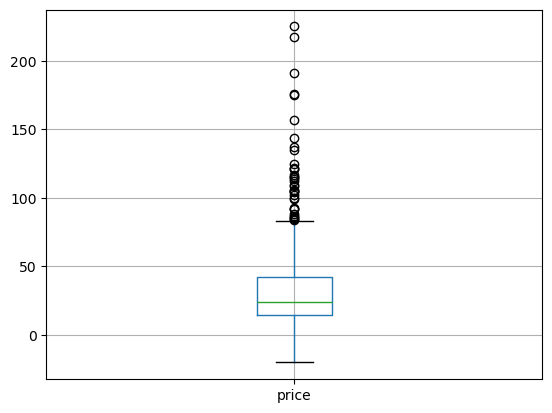

In [761]:
#Création d'une Boite à moustache de la répartition des prix grâce à Pandas

df_combine.boxplot(column="price", vert=True)

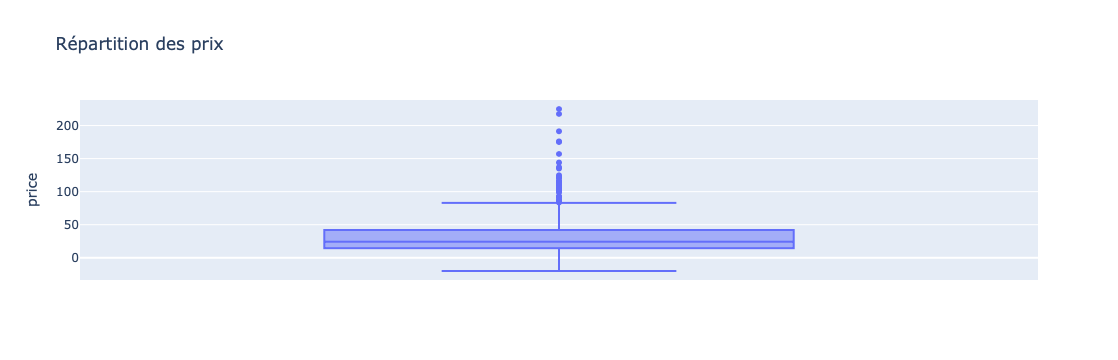

In [763]:
#Autre méthode avec plotly express
#Afficher le graphique
px.box(df_combine, y='price', title='Répartition des prix')

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2 - Exploration par l'utisation de méthodes statistique</h3>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.1 - Identification par le Z-index</h3>
</div>

In [781]:
#Calculer la moyenne du prix
moyenne_prix = df_combine['price'].mean()

#Afficher la moyenne du prix
print("La moyenne du prix est de : {:.2f}".format(moyenne_prix))

#Calculer l'écart-type du prix
ecart_type_prix = df_combine['price'].std()

#Afficher l'écart-type du prix
print("L'écart-type des prix est de : {:.2f}".format(ecart_type_prix))

#Calculer le Z-score 
z_score_price = moyenne_prix / ecart_type_prix
print("Le z-score est de : ",z_score_price)

La moyenne du prix est de : 32.19
L'écart-type des prix est de : 26.71
Le z-score est de :  1.2049866897362609


In [785]:
#Calculer et afficher le Z-score par prix
z_score = (df_combine['price'] - moyenne_prix) / ecart_type_prix

#Ajouter la colonne z_score au DataFrame
df_combine['z_score'] = z_score

#Afficher le résultat
df_combine[["price", "z_score"]]

,price,z_score
0,8.6,-0.883035
1,41.0,0.329900
2,39.0,0.255027
3,59.9,1.037445
4,22.5,-0.362671
...,...,...
822,31.0,-0.044463
823,31.0,-0.044463
824,31.0,-0.044463
825,45.0,0.479645


In [787]:
#Quel est le seuil prix dont z-score est supérieur à 3?
prix_zscore_sup_3 = df_combine[df_combine['z_score'] > 3]

#Afficher les seuil de prix supérieur à 3
prix_zscore_sup_3[['price', 'z_score']]

,price,z_score
24,176.0,5.383793
33,157.0,4.672505
87,115.0,3.100182
157,115.0,3.100182
171,137.0,3.923780
204,217.5,6.937398
233,114.0,3.062746
235,122.0,3.362236
256,124.8,3.467057
257,135.0,3.848907


In [789]:
#Afficher le seuil de prix
print("Le seuil de prix pour le z-score de 3 est de : ", prix_zscore_sup_3["price"].min(), "euros")

Le seuil de prix pour le z-score de 3 est de :  114.0 euros


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 4.2.2 - Identification par l'interval interquartile</h3>
</div>

In [791]:
#Utilisation de la fonction describe de Pandas pour l'etude des mesures de dispersions
description_price = df_combine['price'].describe()

#Afficher le résultat
description_price

count    825.000000
mean      32.187697
std       26.712077
min      -20.000000
25%       14.500000
50%       24.300000
75%       42.000000
max      225.000000
Name: price, dtype: float64

In [793]:
#Définissez un seuil pour les articles "outliers" en prix
Q1 = df_combine['price'].quantile(0.25)
Q3 = df_combine['price'].quantile(0.75)
IQR = Q3 - Q1
#IQR= intervalle interquatile

#Définir les bornes des outliers
borne_inferieure = Q1 - 1.5 * IQR
borne_superieure = Q3 + 1.5 * IQR

#Filtrer et afficher les articles "outliers" en prix
outliers = df_combine[(df_combine['price'] < borne_inferieure) | (df_combine['price'] > borne_superieure)]
outliers

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,product_type,post_title,post_type,post_mime_type,sku_str,_merge,z_score
22,4404.0,1.0,108.5,17.0,instock,52.22,3507,3507,4.0,taxable,Cognac,Cognac Frapin Château de Fontpinot XO,product,NaN,3507,both,2.856846
23,4407.0,1.0,104.0,14.0,instock,46.71,3509,3509,5.0,taxable,Cognac,Cognac Frapin Cigar Blend,product,NaN,3509,both,2.688383
24,4402.0,1.0,176.0,11.0,instock,78.25,3510,3510,3.0,taxable,Cognac,Cognac Frapin VIP XO,product,NaN,3510,both,5.383793
33,4406.0,1.0,157.0,12.0,instock,69.08,7819,7819,4.0,taxable,Cognac,Cognac Frapin Château de Fontpinot 1989 20 Ans...,product,NaN,7819,both,4.672505
53,6214.0,1.0,99.0,9.0,instock,49.62,11601,11601,6.0,taxable,Vin,Domaine des Comtes Lafon Volnay 1er Cru Champa...,product,NaN,11601,both,2.501202
54,5008.0,1.0,105.0,12.0,instock,56.42,11602,11602,7.0,taxable,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,product,NaN,11602,both,2.725820
56,4132.0,1.0,88.4,7.0,instock,44.30,11668,11668,5.0,taxable,Vin,Zind-Humbrecht Pinot Gris Grand Cru Rangen De ...,product,NaN,11668,both,2.104378
87,6215.0,1.0,115.0,14.0,instock,56.45,12790,12790,4.0,taxable,Vin,Domaine des Comtes Lafon Volnay 1er Cru Champa...,product,NaN,12790,both,3.100182
88,5007.0,1.0,105.0,15.0,instock,55.88,12791,12791,3.0,taxable,Vin,Domaine des Comtes Lafon Volnay 1er Cru Santen...,product,NaN,12791,both,2.725820
89,4582.0,1.0,109.6,18.0,instock,53.80,12857,12857,1.0,taxable,Vin,Château de Meursault Puligny-Montrachet 1er Cr...,product,NaN,12857,both,2.898026


In [857]:
#Définissez le nombre d'articles et la proportion de l'ensemble du catalogue "outliers"
#Nombre d'outliers
nombre_outliers = outliers.shape[0]

#Proportion d'outliers dans l'ensemble des articles
proportion_outliers = nombre_outliers / df_combine.shape[0]
print(f"Il y a {nombre_outliers} outliers au total")
print("La proportion d'outliers est de {:.2f}%".format(proportion_outliers * 100))

Il y a 36 outliers au total
La proportion d'outliers est de 4.35%


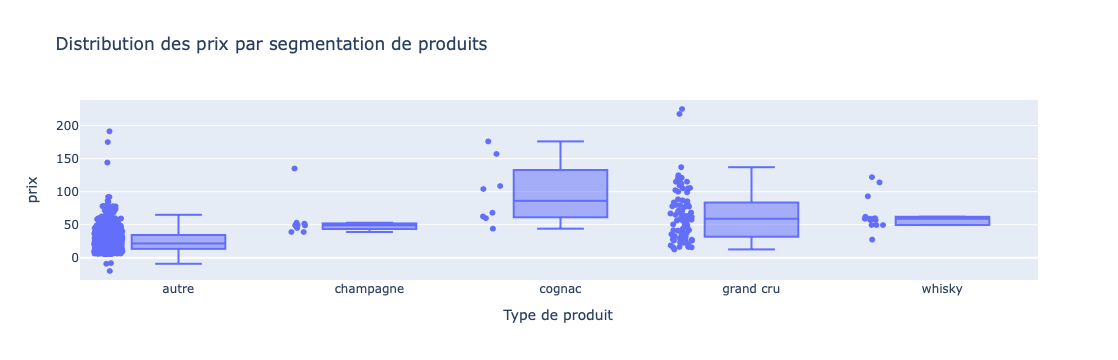

In [859]:
#Selon vous, ces outliers sont-ils justifiés ? Comment le démontrer si cela est possible ?
#2 options sont possible après observation : 
# 1)Démontrer par la segmentation du prix (certains articles portent la mention "1er cru", "Grand Cru")

def segmentation_outliers(post_title):
    for libelle in [post_title]:
        if isinstance(libelle, str):
            libelle = libelle.lower()
            if ("grand" in libelle or "1er" in libelle) and "cru" in libelle:
                return "grand cru"
            elif "champagne" in libelle:
                return "champagne"
            elif "cognac" in libelle:
                return "cognac"
            elif "whisky" in libelle:
                return "whisky"
    return "autre"

df_combine["segmentation_prix"] = df_combine[["post_title"]].apply(lambda row: segmentation_outliers(row["post_title"]), axis=1)
px.box(data_frame=df_combine, x="segmentation_prix", y="price", points="all",
       title= "Distribution des prix par segmentation de produits",
       labels={'segmentation_prix': 'Type de produit', 'price': 'prix'})

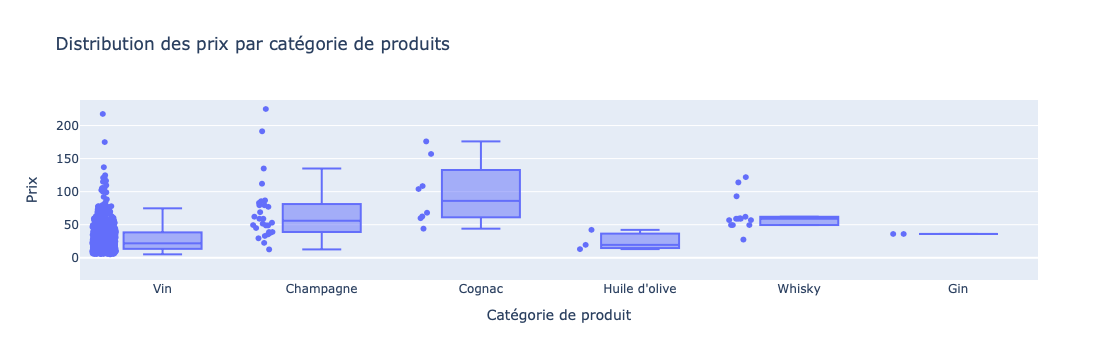

In [861]:
# 2)Démontrer par l'analyse des prix en fonction de la catégorie des produits (Vin, champagne, Whisky, Cognac)

px.box(df_combine, x="product_type", y="price", 
             title="Distribution des prix par catégorie de produits",
             labels={"product_type": "Catégorie de produit", "price": "Prix"},
             points="all")

In [ ]:
#La première option est la meilleure option et apporte une meilleure visibilité pour l'analyse
#De plus, la première option permet de mieux voir dans le détail les outliers que la deuxième option

<div style="background-color: RGB(51,165,182);" >
<h2 style="margin: auto; padding: 20px; color:#fff; ">Etape 5 - Analyse univarié du CA, des quantités vendues, des stocks et de la marge ainsi qu'une analyse multivarié  </h2>
</div>

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.1 - Analyse des ventes en CA</h3>
</div>

In [865]:
##############################
# Calculer le CA su site web #
##############################

#Créez une colonne calculant le CA par article
df_combine['ca_par_article'] = df_combine['price'] * df_combine['total_sales']

#Calculez la somme de la colonne "ca_par_article"
chiffre_affaires = df_combine['ca_par_article'].sum()
print(f"Le chiffre d'affaires total est de : {chiffre_affaires} euros HT")


#Ce résultat correspond au chiffre d'affaires du site web

Le chiffre d'affaires total est de : 143505.1 euros HT


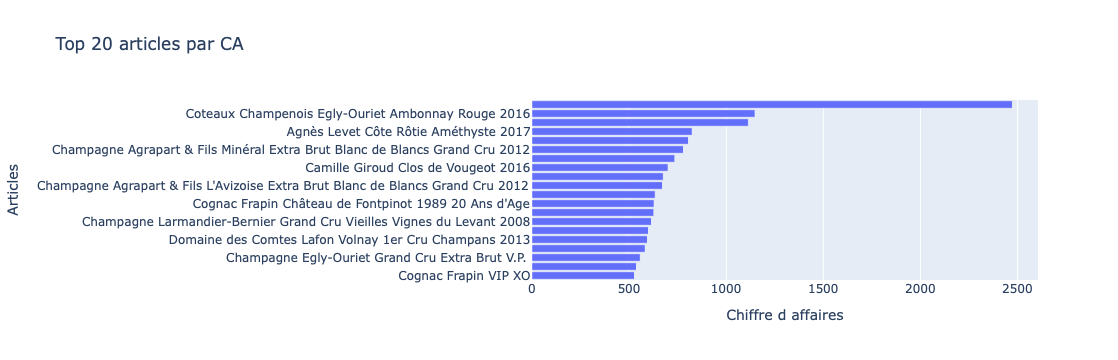

In [867]:
###############################
# Palmares des articles en CA #
###############################

#Effectuer le tri dans l'ordre décroissant du CA du dataset df_combine
df_combine = df_combine.sort_values(by='ca_par_article', ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_combine.reset_index(drop=True, inplace=True)

#Créer une colonne somme cumulative
df_combine["ca_cumule"] = df_combine["ca_par_article"].cumsum()

#Calculer le pourcentage cumulatif
df_combine["ca_cumule_%"] = df_combine["ca_cumule"] / df_combine["ca_par_article"].sum()

#Afficher les 20 premiers articles en CA
#Affichage décroissant en affichant les noms des produits + horizontal pour une meilleure visibilité

#Graphique en barre des 20 premiers articles avec plotly express
top_20_articles = df_combine.sort_values(by='ca_par_article', ascending=False).head(20)
px.bar(top_20_articles[:20][::-1], x='ca_par_article', y='post_title', title="Top 20 articles par CA",
             labels={'post_title': 'Articles', 'ca_par_article': 'Chiffre d affaires'})

In [875]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part du CA de la ligne dans le dataset
df_combine['part_du_ca'] = df_combine['ca_par_article'] / chiffre_affaires

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_combine['ca_cumule'] = df_combine['part_du_ca'].cumsum()

#Créer une colonne réalisant le total en %
df_combine["total_ca_cumule_%"] = df_combine["ca_cumule"] / df_combine["part_du_ca"].sum()

#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% du CA
nombre_articles_80 = df_combine[df_combine['total_ca_cumule_%'] <= 0.8].shape[0]
print(f"Le nombre d'articles représentant 80% du CA est de : {nombre_articles_80}")

#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
proportion_articles_80 = nombre_articles_80 / df_combine.shape[0]
print(f"La proportion d'articles représentant 80% du CA est de : {proportion_articles_80:.2%}")

Le nombre d'articles représentant 80% du CA est de : 433
La proportion d'articles représentant 80% du CA est de : 52.36%


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.2 - Analyse des ventes en Quantités</h3>
</div>

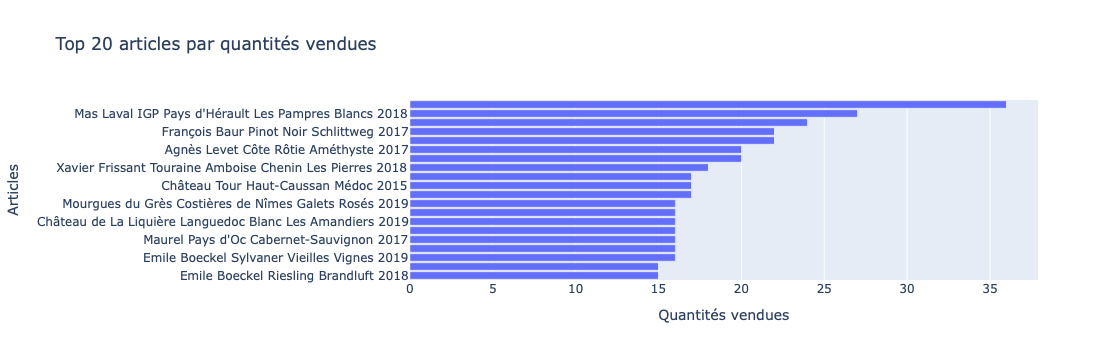

In [877]:
#####################################
# Palmares des articles en quantité #
#####################################

#qty = quantité
#Effectuer le tri dans l'ordre décroissant de quantités vendues du dataset df_combine
df_combine_qty = df_combine.sort_values(by='total_sales', ascending=False)

#Réinitialiser l'index du dataset par un reset_index
df_combine_qty = df_combine_qty.reset_index(drop=True)

#Afficher les 20 premiers articles en quantité
top_20_qty = df_combine_qty.sort_values(by='total_sales', ascending=False).head(20)

#Graphique en barre des 20 premiers articles avec plotly express
px.bar(top_20_qty[:20][::-1], x='total_sales', y='post_title', title='Top 20 articles par quantités vendues',
             labels={'post_title': 'Articles', 'total_sales': 'Quantités vendues'})

In [891]:
#############################
# Calculer le 20 / 80 en CA #
#############################

#Créer une colonne calculant la part en quantité de la ligne dans le dataset
df_combine['part_quantité'] = df_combine['stock_quantity'] / df_combine['stock_quantity'].sum()

#Créer une colonne réalisant la somme cumulative de la colonne précedemment créée
df_combine['cumul_part_quantité'] = df_combine['part_quantité'].cumsum()

#Grâce au deux colonnes créées précedemment, calculer le nombre d'articles représentant 80% des ventes en quantité
nb_articles_80_quantité = df_combine[df_combine['cumul_part_quantité'] <= 0.80].shape[0]
print(f"Le nombre d'articles représentant 80% des ventes en quantité est de : {nb_articles_80_quantité}")

#Afficher la proportion que représentent ce groupe d'articles dans le catalogue entier du site web
proportion_articles_80 = nb_articles_80_quantité / df_combine.shape[0] * 100
print(f"La proportion d'articles représentant 80% des ventes est de : {proportion_articles_80:.2f}%")

Le nombre d'articles représentant 80% des ventes en quantité est de : 589
La proportion d'articles représentant 80% des ventes est de : 71.22%


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.3 - Analyse des stocks</h3>
</div>

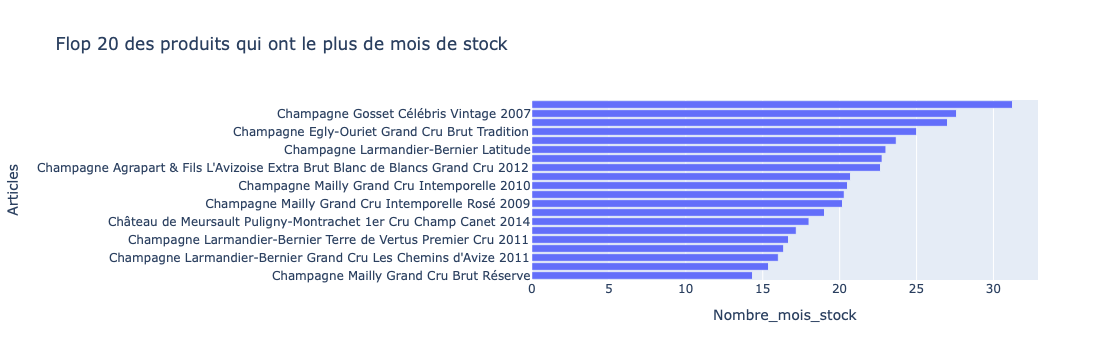

In [917]:
######################################
# Calcule le nombre de mois de stock #
######################################

#Import de numpy 
import numpy as np 

#Création de la colonne Rotation de stock
df_combine["Nombre_mois_stock"] = df_combine["stock_quantity"] / df_combine["total_sales"]

#Remplacement des "inf" par 0
df_combine['Nombre_mois_stock'] = df_combine['Nombre_mois_stock'].replace([np.inf], 0)

#Effectuer le tri dans l'ordre décroissant du nombre de mois de stock dans le dataset df_combine
df_combine_stock = df_combine.sort_values(by='Nombre_mois_stock', ascending=False)

#Graphique en barre du flop 20 des produits qui ont le plus de mois de stock
flop_20_stock = df_combine_stock.sort_values(by='Nombre_mois_stock', ascending=False).head(20)
px.bar(flop_20_stock[:20][::-1], x='Nombre_mois_stock', y='post_title', title='Flop 20 des produits qui ont le plus de mois de stock',
             labels={'post_title': 'Articles'})

In [903]:
####################################
# Valorisation des stocks en euros #
####################################

#Création de la colonne Valorisation des stocks en euros
df_combine['valorisation_stock_euros'] = df_combine['stock_quantity'] * df_combine['price']

#Calculer la somme de la colonne "Valorisation_stock_euros"
valorisation_stock_total = df_combine['valorisation_stock_euros'].sum()
print(f"La valorisation totale du stock est de: {valorisation_stock_total} euros")

#Mois en stock
valorisation_stock_mois = df_combine['valorisation_stock_euros'].sum() / df_combine["ca_par_article"].sum()
print(f"Il y a {valorisation_stock_mois:.1f} mois de stock")

La valorisation totale du stock est de: 531628.8 euros
Il y a 3.7 mois de stock


In [905]:
##############################################
# Valorisation du nombre de produit en stock #
##############################################

#Calculer la somme de la colonne stock quantity
stock_total = df_combine['stock_quantity'].sum()
print(f"Nous avons au total {stock_total} articles en stock")

Nous avons au total 17811.0 articles en stock


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.4 - Analyse du taux de marge</h3>
</div>

In [919]:
############################
# Analyse du taux de marge #
############################

#Création de la colonne prix HT
df_combine['prix_HT'] = df_combine['price'] / 1.2  # 20% de TVA 

#Création de la colonne Taux de marge
df_combine['taux_marge'] = (df_combine['prix_HT'] - df_combine['purchase_price']) / df_combine['prix_HT']

#Afficher le prix minimum de la colonne "taux_marge"
print(f"Le prix minimum pour le taux de marge est de : {df_combine['taux_marge'].min()}")

#Afficher le prix maximum de la colonne "taux_marge"
print(f"Le prix maximum pour le taux de marge est de : {df_combine['taux_marge'].max()}")

Le prix minimum pour le taux de marge est de : -6.3498814229249
Le prix maximum pour le taux de marge est de : 1.651


In [921]:
#Affichage de la ligne avec un taux de marge inférieur à 0
articles_marge_negative = df_combine[df_combine['taux_marge'] < 0]
articles_marge_negative

,product_id,onsale_web,price,stock_quantity,stock_status,purchase_price,id_web,sku,total_sales,tax_status,product_type,post_title,post_type,z_score,segmentation_prix,ca_par_article,ca_cumule,ca_cumule_%,part_du_ca,total_ca_cumule_%,part_quantité,cumul_part_quantité,valorisation_stock_euros,Nombre_mois_stock,prix_HT,taux_marge
689,4355.0,1.0,12.65,97.0,instock,77.48,12589,12589,0.0,taxable,Champagne,Champagne Egly-Ouriet Grand Cru Blanc de Noirs,product,-0.731418,grand cru,0.0,1.0,1.0,0.0,1.0,0.005446,0.929650,1227.05,0.0,10.541667,-6.349881
725,4864.0,0.0,8.30,0.0,outofstock,9.99,15154,NaN,NaN,NaN,NaN,NaN,NaN,-0.894266,autre,NaN,NaN,NaN,NaN,NaN,0.000000,0.938690,0.00,NaN,6.916667,-0.444337
772,6324.0,0.0,92.00,18.0,instock,99.00,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2.239148,autre,NaN,NaN,NaN,NaN,NaN,0.001011,0.948403,1656.00,NaN,76.666667,-0.291304
822,7196.0,0.0,31.00,55.0,instock,31.20,NaN,NaN,NaN,NaN,NaN,NaN,NaN,-0.044463,autre,NaN,NaN,NaN,NaN,NaN,0.003088,0.996463,1705.00,NaN,25.833333,-0.207742


In [338]:
print("Il est important de noter que 4 produits ont des taux de marge négatif.")
print("De plus, le champagne Egly-Ouriet à un taux de -6.34.")

Il est important de noter que 4 produits ont des taux de marge négatif.
De plus, le champagne Egly-Ouriet à un taux de -6.34.


In [923]:
#Création d'un dataframe avec les taux positifs
df_taux_positif = df_combine[df_combine['taux_marge'] >= 0]

#Afficher le prix minimum de la colonne "taux_marge" (taux positif)
min_taux_marge = round(df_taux_positif['taux_marge'].min(), 2)
print(f"Le prix minimum pour le taux de marge est de : {min_taux_marge}")

#Afficher le prix maximum de la colonne "taux_marge" (taux positif)
max_taux_marge = round(df_taux_positif['taux_marge'].max(), 2)
print(f"Le prix maximum pour le taux de marge est de : {max_taux_marge}")

#Affichage des résultats arrondis pour une meilleure visibilité

Le prix minimum pour le taux de marge est de : 0.23
Le prix maximum pour le taux de marge est de : 1.65


In [925]:
#Création d'un dataframe avec le taux de marge moyen par type de produit
df_marge_moyenne_par_type = df_combine.groupby('product_type')['taux_marge'].mean().reset_index()

#Trier le dataframe par 'taux_marge' en ordre décroissant pour une meilleure visibilité
df_marge_moyenne_par_type = df_marge_moyenne_par_type.sort_values(by='taux_marge', ascending=True)
df_marge_moyenne_par_type

,product_type,taux_marge
0,Champagne,0.047929
3,Huile d'olive,0.249982
4,Vin,0.380123
2,Gin,0.428000
5,Whisky,0.449189
1,Cognac,0.450676


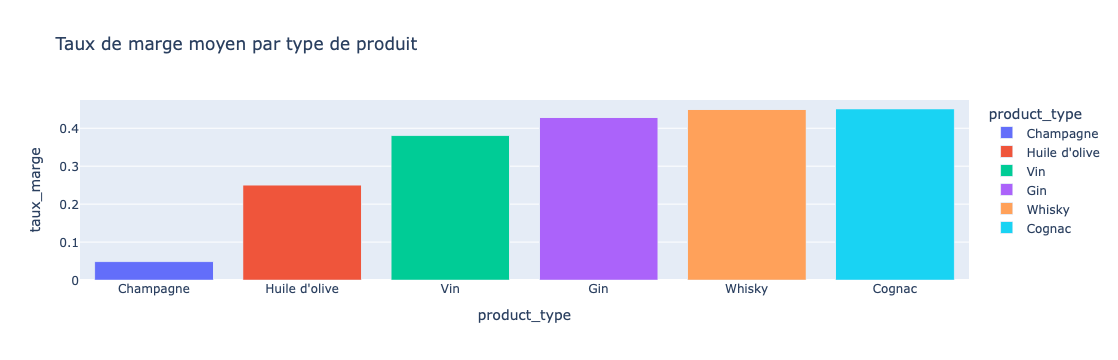

In [927]:
#Affichage dans un graphique du taux de marge par type de produit
px.bar(df_marge_moyenne_par_type, x='product_type', y='taux_marge', title='Taux de marge moyen par type de produit', color='product_type')

In [937]:
print("On observe que les taux de marge sont différents en fonction du type de produits avec des gros écarts entre le Champagne et le Cognac")
print("On peut constater que le cognac à le taux de marge le plus élevé avec 0.45")
print("A l'inverse, on observe que le champagne est décalé par rapport aux autres alcool")
print("On peut également voir que les 3 alcools fort ont des taux de marge assez proche les uns des autres et au-dessus de 40%")
print("\nIl serait bon d'envisager de changer les prix de ventes des champagnes en proposant par exemple d'augmenter leurs prix de vente")
print("Ce qui aura un impact direct sur le taux de marge.")
print("On pourrait par exemple les proposer pour le champagne 'Egly-Ourlet' ")
print("Sachant que son prix d'achat HT unitaire est de 77.48. Cela revient donc avec la marge appliquée à 81,38052 de prix HT")
print("On ajoute à ceci la TVA à 20% donc 81,38052 * 1.2 = 97.65663 donc 97.66e TTC")
print("En sachant que nous avons 97 articles en stock, cela nous apportera 7893.91e de CA HT")

On observe que les taux de marge sont différents en fonction du type de produits avec des gros écarts entre le Champagne et le Cognac
On peut constater que le cognac à le taux de marge le plus élevé avec 0.45
A l'inverse, on observe que le champagne est décalé par rapport aux autres alcool
On peut également voir que les 3 alcools fort ont des taux de marge assez proche les uns des autres et au-dessus de 40%

Il serait bon d'envisager de changer les prix de ventes des champagnes en proposant par exemple d'augmenter leurs prix de vente
Ce qui aura un impact direct sur le taux de marge.
On pourrait par exemple les proposer pour le champagne 'Egly-Ourlet' 
Sachant que son prix d'achat HT unitaire est de 77.48. Cela revient donc avec la marge appliquée à 81,38052 de prix HT
On ajoute à ceci la TVA à 20% donc 81,38052 * 1.2 = 97.65663 donc 97.66e TTC
En sachant que nous avons 97 articles en stock, cela nous apportera 7893.91e de CA HT


<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.5 - Analyse des correlations entre les variables stock, sales et price</h3>
</div>

<Axes: >

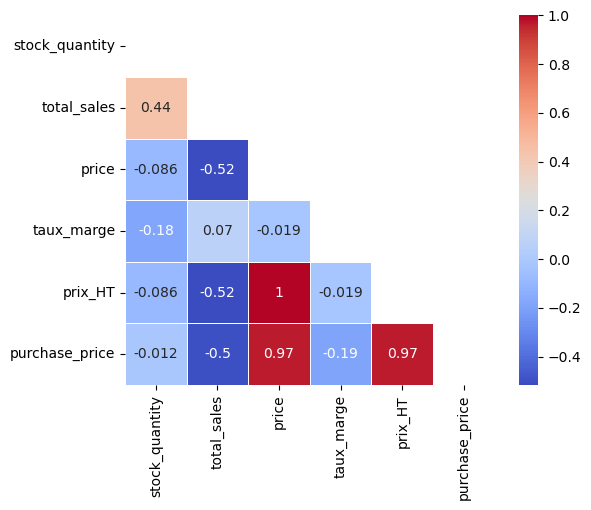

In [941]:
############################
# Analyse des correlations #
############################

#Importation de Seaborn
import seaborn as sns

#Création d'un heatmap de correlation avec les variables stock, sales et price
#Sélection des colonnes pertinentes pour réaliser l'heatmap (stock, sales, price)
df_corr = df_combine[['stock_quantity', 'total_sales', 'price', 'taux_marge', 'prix_HT', 'purchase_price']]

#Calcul de la matrice de corrélation
corr_matrix = df_corr.corr()

#Création d'un masque pour afficher que la moitié de la heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))

#Création de la heatmap avec Seaborn
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", mask=mask, square=True, linewidths=0.5)

#On peut également créer un mask pour afficher qu'une demi heatmap

In [947]:
#Que peut-on conclure des corrélations ?

print("On peut en conclure que la corrélation entre les prix d'achat, les prix HT et les marges sont très fortes et positives")
print("Les variables prix_HT et prix d'achat sont très fortement corrélées (0.97).")
print("Cela indique que les prix_HT sont très fortement liés aux prix d'achat")
print("Il en est de même pour les variables prix et prix d'achat (0.97)")
print("Il y a également une corrélation positive mais plus modéré concernant le total des ventes et la quantité de stock (0.44)")
print("Cela indique que si la quantité de stock augmente, le total des ventes va également augmenter")
print("\nA l'inverse, la corrélation est négative pour la variable prix et le total des ventes. (0.52")
print("Cela signifie que lorsque l'on augmente le prix d'achat, les ventes auront tendance à baisser")
print("Il en est de même pour la variable concernant le total des ventes et le prix d'achat (0.50)")
print("Les produits avec un fort prix d'achat auront tendance à moins bien se vendre.")
print("De même, on peut ajouter que si le prix d'achat est élevé, le prix de vente le sera également et le stock diminuera moins rapidement")
print("\nEnfin, la corrélation parfaite entre le prix HT et le prix de vente indique qu'il évolue dans le sens")
print("Et ceci s'explique par la TVA (20%) qui permet aux deux variables d'évoluer dans le même sens")

On peut en conclure que la corrélation entre les prix d'achat, les prix HT et les marges sont très fortes et positives
Les variables prix_HT et prix d'achat sont très fortement corrélées (0.97).
Cela indique que les prix_HT sont très fortement liés aux prix d'achat
Il en est de même pour les variables prix et prix d'achat (0.97)
Il y a également une corrélation positive mais plus modéré concernant le total des ventes et la quantité de stock (0.44)
Cela indique que si la quantité de stock augmente, le total des ventes va également augmenter

A l'inverse, la corrélation est négative pour la variable prix et le total des ventes. (0.52
Cela signifie que lorsque l'on augmente le prix d'achat, les ventes auront tendance à baisser
Il en est de même pour la variable concernant le total des ventes et le prix d'achat (0.50)
Les produits avec un fort prix d'achat auront tendance à moins bien se vendre.
De même, on peut ajouter que si le prix d'achat est élevé, le prix de vente le sera également e

<div style="border: 1px solid RGB(51,165,182);" >
<h3 style="margin: auto; padding: 20px; color: RGB(51,165,182); ">Etape 5.6 - Mettre à disposition la nouvelle table sur un fichier Excel</h3>
</div>

In [ ]:
#Mettre le dataset df_combine sur un fichier Excel
#Cette étape peut-être utile pour partager le résultat du dataset obtenu pour le partager avec les équipes.  
df_combine.to_excel("df_combine.xlsx", index=False)